Heart Disease Prediction Model

In [2]:
## 1. Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import  seaborn as sns

In [3]:
# Load Heart Disease dataset from UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df = pd.read_csv(url, names=columns, na_values='?')
print("Dataset Loaded Successfully!")
print(f"Dataset Shape: {df.shape}")

Dataset Loaded Successfully!
Dataset Shape: (303, 14)


In [4]:
print("Dataset Information")
print(df.info())
print("\n" + "="*50 + "\n")

print("Target Distribution:")
print(df['target'].value_counts())
print("\n" + "="*50 + "\n")

print("Missing Values")
print(df.isnull().sum())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


Target Distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


Missing Values
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs   

In [5]:
#Healthy and Diseased Patients Count
df['target'] = df['target'].apply(lambda x:1 if x > 0 else 0)

print("Target Distribution")
print(df['target'].value_counts())
print(f"\nHealthy Patients(0): {(df['target']==0).sum()}")
print(f"\nUnhealthy Patients(1): {(df['target']==1).sum()}")

Target Distribution
target
0    164
1    139
Name: count, dtype: int64

Healthy Patients(0): 164

Unhealthy Patients(1): 139


In [6]:
# Check missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values per Column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6


In [7]:
# Drop rows with missing values
df_clean = df.dropna()

print(f"Original dataset: {df.shape[0]} rows")
print(f"After removing missing values: {df_clean.shape[0]} rows")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

# Verify no missing values remain
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")

Original dataset: 303 rows
After removing missing values: 297 rows
Rows removed: 6

Missing values remaining: 0


In [8]:
# Separate features (X) and target (y)
X = df_clean.drop('target', axis=1)  # All columns except 'target'
y = df_clean['target']                # Only the 'target' column

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

Features shape: (297, 13)
Target shape: (297,)

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution: \n{y_train.value_counts()}")
print(f"\nTest Target Distribution: \n{y_test.value_counts()}")



Training set: 237 samples
Test set: 60 samples

Training target distribution: 
target
0    128
1    109
Name: count, dtype: int64

Test Target Distribution: 
target
0    32
1    28
Name: count, dtype: int64


In [10]:
#Model Trained with Logistic Regression for accuracy check
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("="*50)
print("🎉 YOUR FIRST MODEL IS TRAINED!")
print("="*50)
print(f"\nModel: Logistic Regression")
print(f"Accuracy on test set: {accuracy:.2%}")
print(f"\nThis means the model correctly predicted {accuracy:.2%} of cases!")

🎉 YOUR FIRST MODEL IS TRAINED!

Model: Logistic Regression
Accuracy on test set: 83.33%

This means the model correctly predicted 83.33% of cases!


<function confusion_matrix at 0x79b5b78c6fc0>
[[28  4]
 [ 6 22]]

Breakdown:
True Negatives (Correctly predicted Healthy): 28
False Positives (Healthy predicted as Disease): 4
False Negatives (Disease predicted as Healthy): 6
True Positives (Correctly predicted Disease): 22


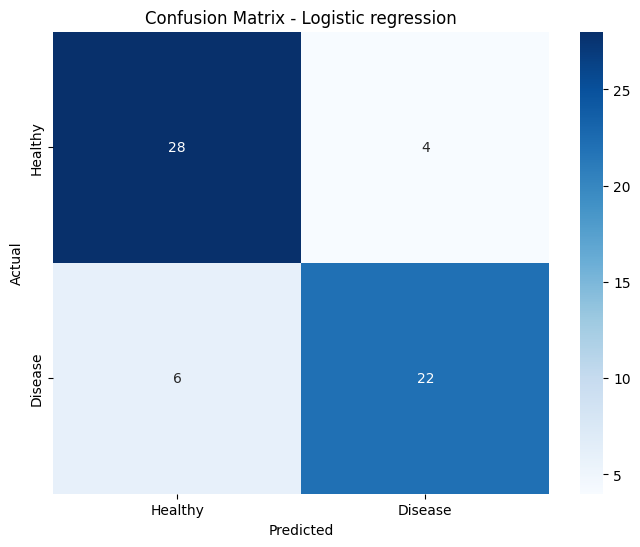


DETAILED METRICS:
              precision    recall  f1-score   support

     Healthy       0.82      0.88      0.85        32
     Disease       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



In [11]:
#Model Training with Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

print(confusion_matrix)
print(cm)
print("\nBreakdown:")
print(f"True Negatives (Correctly predicted Healthy): {cm[0,0]}")
print(f"False Positives (Healthy predicted as Disease): {cm[0,1]}")
print(f"False Negatives (Disease predicted as Healthy): {cm[1,0]}")
print(f"True Positives (Correctly predicted Disease): {cm[1,1]}")

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Disease'],
            yticklabels=['Healthy', 'Disease'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic regression')
plt.show()

# Detailed metrics
print("\n" + "="*50)
print("DETAILED METRICS:")
print("="*50)

print(classification_report(y_test, y_pred, target_names=['Healthy', 'Disease']))



In [12]:
#Model Trained with RandomForest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("="*50)
print("🌲 RANDOM FOREST MODEL")
print("="*50)
print(f"Accuracy: {accuracy_rf:.2%}")
print(f"\nConfusion Matrix:")
print(cm_rf)
print(f"\nFalse Negatives (Dangerous): {cm_rf[1,0]}")
print("\nDetailed Report:")

print(classification_report(y_test, y_pred_rf, target_names = ['Healthy', 'Disease']))

🌲 RANDOM FOREST MODEL
Accuracy: 85.00%

Confusion Matrix:
[[29  3]
 [ 6 22]]

False Negatives (Dangerous): 6

Detailed Report:
              precision    recall  f1-score   support

     Healthy       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



In [13]:
pip install xgboost

In [14]:
#Model Trained with XGBoost
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("="*50)
print("⚡ XGBOOST MODEL")
print("="*50)
print(f"Accuracy: {accuracy_xgb:.2%}")
print(f"\nConfusion Matrix:")
print(cm_xgb)
print(f"\nFalse Negatives (Dangerous): {cm_xgb[1,0]}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Healthy', 'Disease']))

⚡ XGBOOST MODEL
Accuracy: 86.67%

Confusion Matrix:
[[29  3]
 [ 5 23]]

False Negatives (Dangerous): 5

Detailed Report:
              precision    recall  f1-score   support

     Healthy       0.85      0.91      0.88        32
     Disease       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:12:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


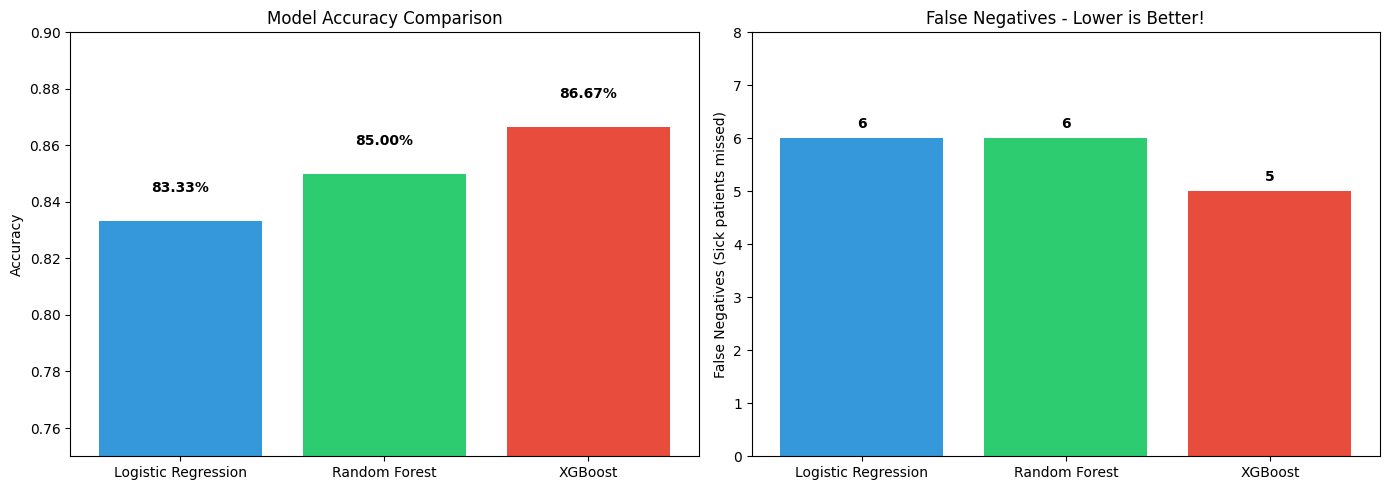


🏆 Winner: XGBoost (Best accuracy + Fewest missed sick patients)


In [15]:
# Model comparison
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [accuracy, accuracy_rf, accuracy_xgb]
false_negatives = [6, 6, 5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1.bar(models, accuracies, color=['#3498db', '#2ecc71', '#e74c3c'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim([0.75, 0.90])
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# False Negatives comparison (lower is better!)
ax2.bar(models, false_negatives, color=['#3498db', '#2ecc71', '#e74c3c'])
ax2.set_ylabel('False Negatives (Sick patients missed)')
ax2.set_title('False Negatives - Lower is Better!')
ax2.set_ylim([0, 8])
for i, v in enumerate(false_negatives):
    ax2.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🏆 Winner: XGBoost (Best accuracy + Fewest missed sick patients)")

In [16]:
import pickle

# Save the XGBoost model
with open('heart_disease_model.pkl', 'wb') as file:
    pickle.dump(xgb_model, file)

print("✅ Model saved as 'heart_disease_model.pkl'")
print("You can load this later and use it for predictions!")

✅ Model saved as 'heart_disease_model.pkl'
You can load this later and use it for predictions!


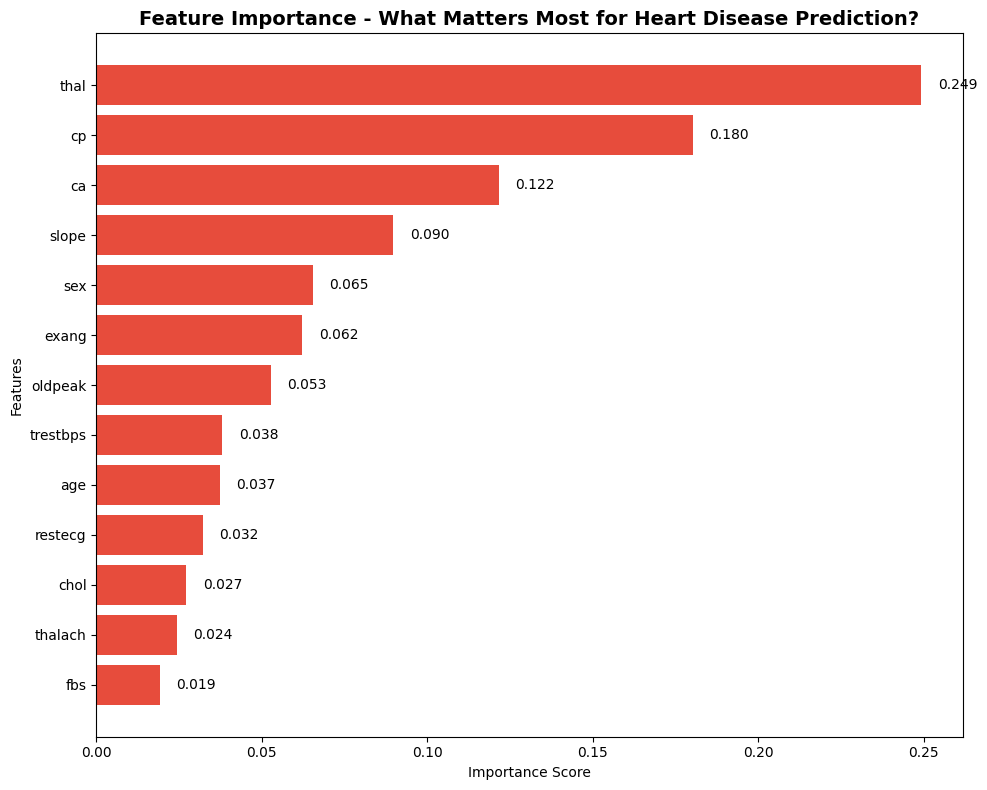

🏆 TOP 5 MOST IMPORTANT FEATURES:
thal            → 0.2493
cp              → 0.1802
ca              → 0.1217
slope           → 0.0897
sex             → 0.0655


In [17]:
# Get feature importance from XGBoost
feature_importance = xgb_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#e74c3c')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - What Matters Most for Heart Disease Prediction?', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top

# Add values on bars
for i, v in enumerate(importance_df['Importance']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# Print top 5 features
print("🏆 TOP 5 MOST IMPORTANT FEATURES:")
print("="*50)
for idx, row in importance_df.head(5).iterrows():
    print(f"{row['Feature']:15s} → {row['Importance']:.4f}")

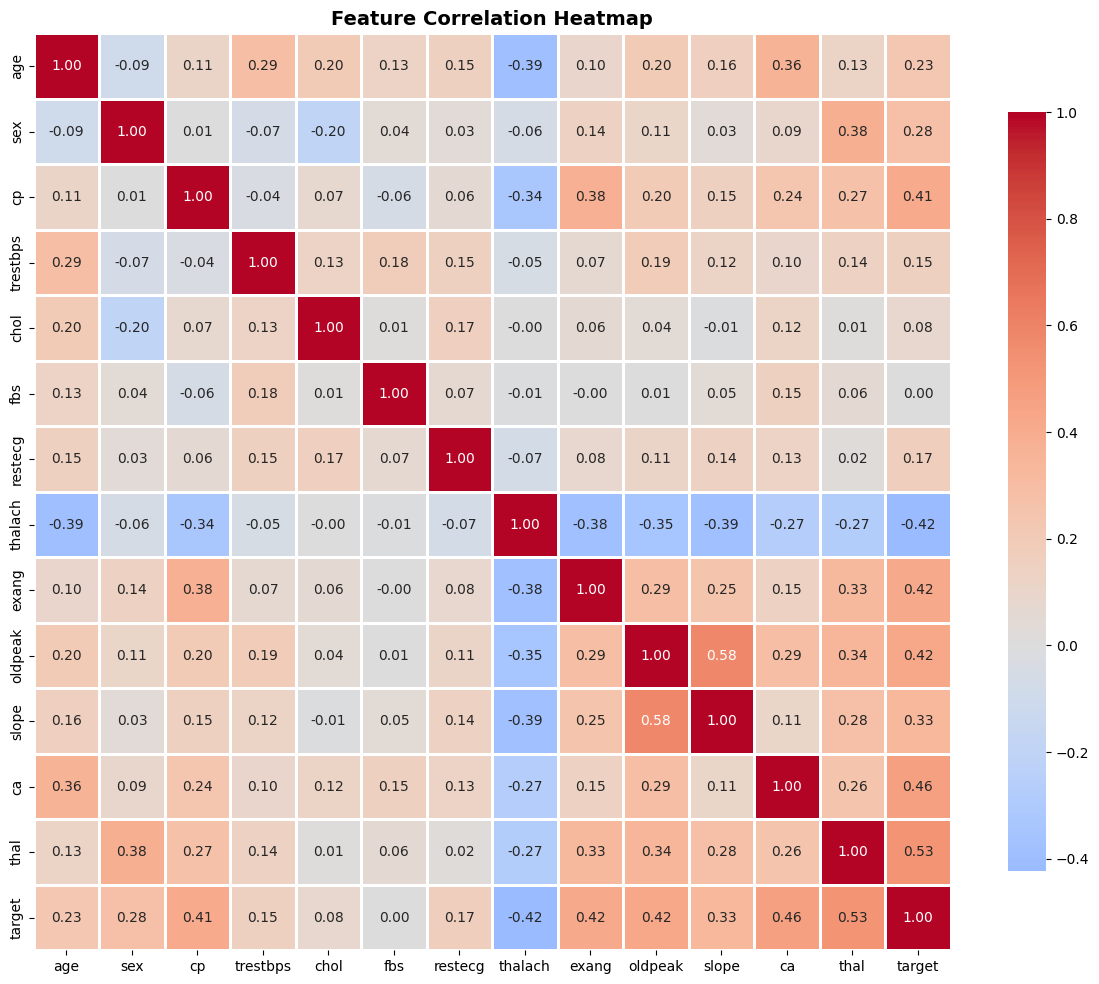


📊 CORRELATION WITH HEART DISEASE:
target      1.000000
thal        0.526640
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: target, dtype: float64


In [18]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_clean.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find features most correlated with target
target_corr = correlation_matrix['target'].sort_values(ascending=False)
print("\n📊 CORRELATION WITH HEART DISEASE:")
print("="*50)
print(target_corr)

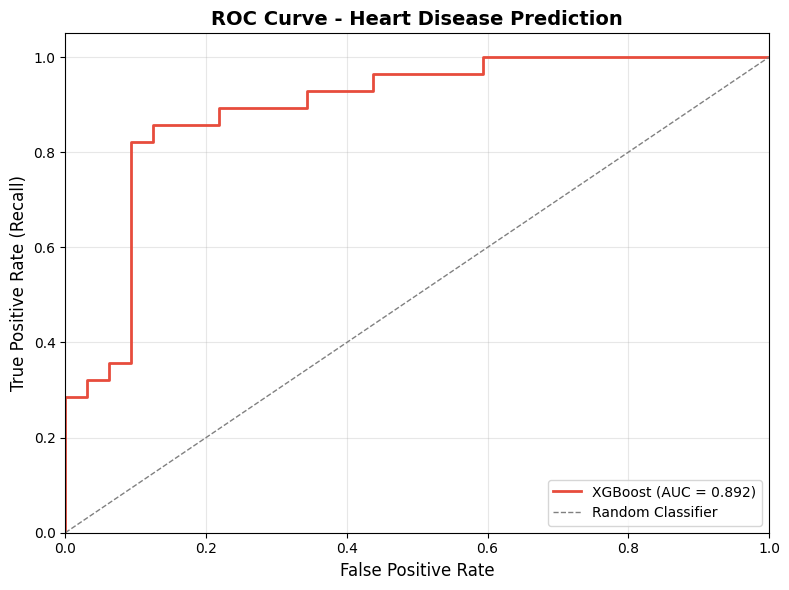

🎯 ROC-AUC Score: 0.892
(Closer to 1.0 = Better model)


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability predictions (not just 0/1)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve - Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"🎯 ROC-AUC Score: {roc_auc:.3f}")
print("(Closer to 1.0 = Better model)")

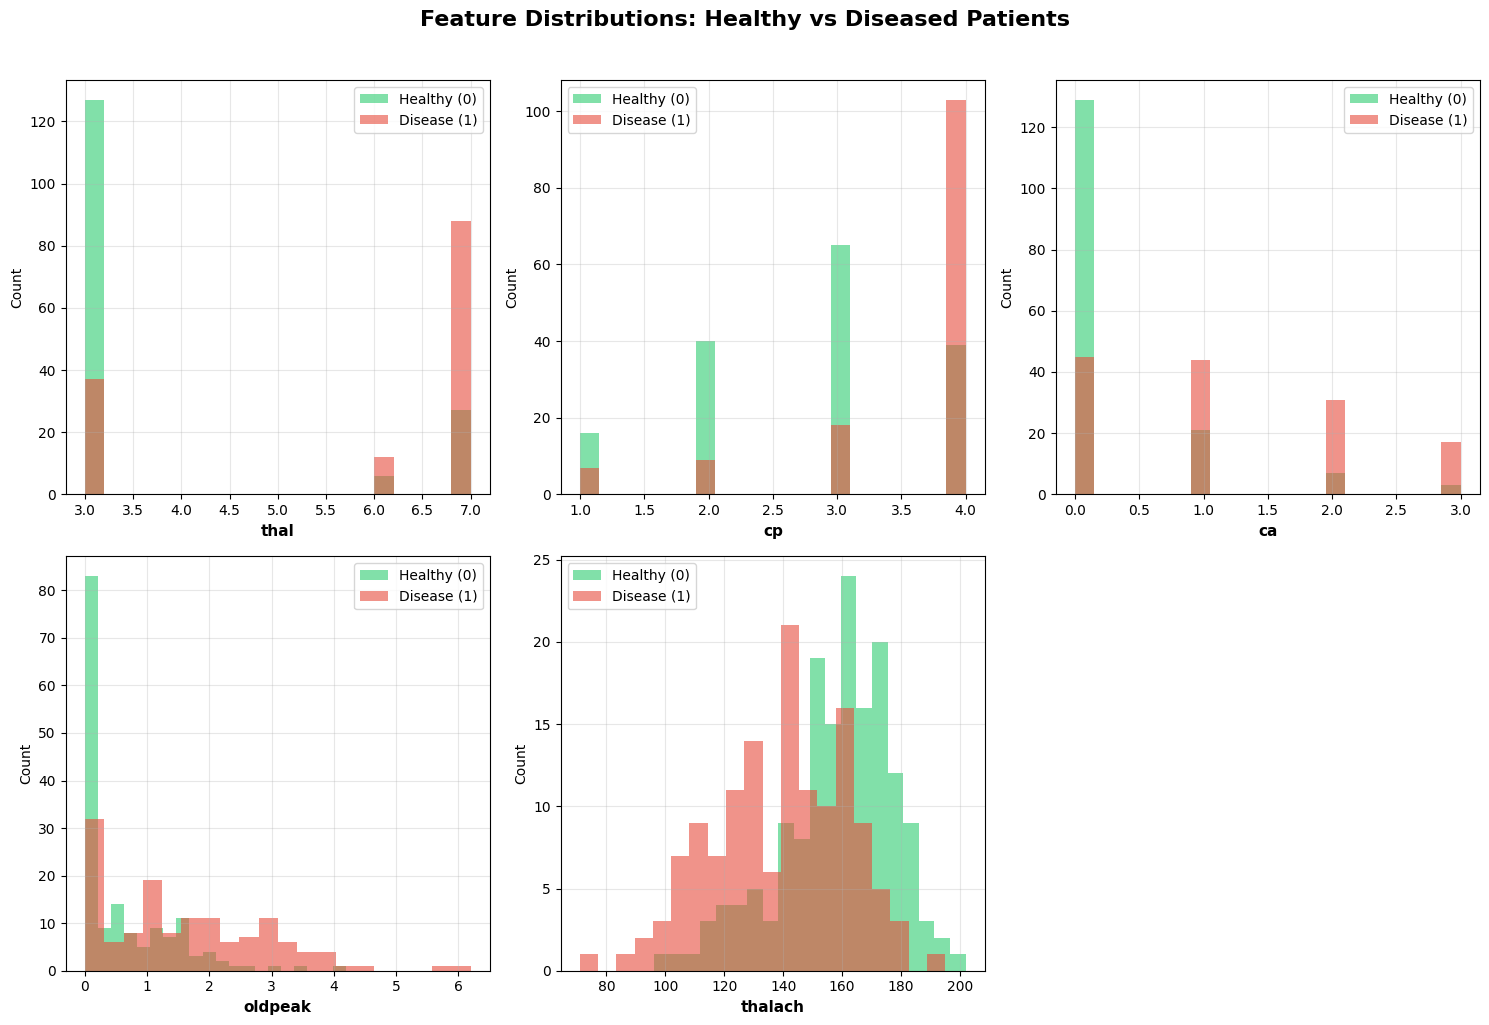

In [20]:
# Select top 5 important features for visualization
top_features = ['thal', 'cp', 'ca', 'oldpeak', 'thalach']

# Create distribution plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    # Separate data by target
    healthy = df_clean[df_clean['target'] == 0][feature]
    diseased = df_clean[df_clean['target'] == 1][feature]

    # Plot distributions
    axes[idx].hist(healthy, alpha=0.6, label='Healthy (0)', bins=20, color='#2ecc71')
    axes[idx].hist(diseased, alpha=0.6, label='Disease (1)', bins=20, color='#e74c3c')
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Count')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

# Remove extra subplot
fig.delaxes(axes[5])

plt.suptitle('Feature Distributions: Healthy vs Diseased Patients',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [24]:
print("="*60)
print("🏥 HEART DISEASE PREDICTION MODEL - FINAL REPORT")
print("="*60)
print(f"\n📊 DATASET SUMMARY:")
print(f"   • Total patients: {len(df_clean)}")
print(f"   • Healthy: {(df_clean['target']==0).sum()} ({(df_clean['target']==0).sum()/len(df_clean)*100:.1f}%)")
print(f"   • Diseased: {(df_clean['target']==1).sum()} ({(df_clean['target']==1).sum()/len(df_clean)*100:.1f}%)")
print(f"   • Features used: {X.shape[1]}")

print(f"\n🤖 MODEL PERFORMANCE:")
print(f"   • Algorithm: XGBoost")
print(f"   • Test Accuracy: {accuracy_xgb:.2%}")
print(f"   • ROC-AUC Score: {roc_auc:.3f}")
print(f"   • Recall (Disease Detection): {cm_xgb[1,1]/(cm_xgb[1,0]+cm_xgb[1,1]):.2%}")
print(f"   • Precision (Disease): {cm_xgb[1,1]/(cm_xgb[0,1]+cm_xgb[1,1]):.2%}")

print(f"\n🔍 TOP 3 PREDICTIVE FEATURES:")
for idx, row in importance_df.head(3).iterrows():
    print(f"   {idx+1}. {row['Feature']:10s} (Importance: {row['Importance']:.3f})")

print(f"\n⚠️  MODEL ERRORS:")
print(f"   • False Negatives (Missed diseases): {cm_xgb[1,0]}")
print(f"   • False Positives (False alarms): {cm_xgb[0,1]}")

print(f"\n✅ CONCLUSION:")
print(f"   This model achieved {accuracy_xgb:.1%} accuracy with an excellent")
print(f"   ROC-AUC score of {roc_auc:.3f}, making it suitable for preliminary")
print(f"   heart disease screening. The model correctly identifies")
print(f"   {cm_xgb[1,1]/(cm_xgb[1,0]+cm_xgb[1,1]):.1%} of disease cases.")
print("="*60)

🏥 HEART DISEASE PREDICTION MODEL - FINAL REPORT

📊 DATASET SUMMARY:
   • Total patients: 297
   • Healthy: 160 (53.9%)
   • Diseased: 137 (46.1%)
   • Features used: 13

🤖 MODEL PERFORMANCE:
   • Algorithm: XGBoost
   • Test Accuracy: 86.67%
   • ROC-AUC Score: 0.892
   • Recall (Disease Detection): 82.14%
   • Precision (Disease): 88.46%

🔍 TOP 3 PREDICTIVE FEATURES:
   13. thal       (Importance: 0.249)
   3. cp         (Importance: 0.180)
   12. ca         (Importance: 0.122)

⚠️  MODEL ERRORS:
   • False Negatives (Missed diseases): 5
   • False Positives (False alarms): 3

✅ CONCLUSION:
   This model achieved 86.7% accuracy with an excellent
   ROC-AUC score of 0.892, making it suitable for preliminary
   heart disease screening. The model correctly identifies
   82.1% of disease cases.
